## 0. Prerequisites

- `pm4py-ucm` installed (`pip install pm4py-ucm`, or
  `pip install -e .` from the repo root).
- `graphviz` binary on `PATH` — see https://graphviz.org/download/.
- `pandas` and `pm4py` (transitive dependencies, installed
  automatically).
- The notebook works best in JupyterLab / VS Code with image
  rendering enabled.

# pm4py-ucm — End-to-end tutorial

This notebook is a guided tour of [**pm4py-ucm**](https://github.com/ProcessMining-uOttawa/pm4py-ucm),
a drop-in extension to [PM4Py](https://github.com/process-intelligence-solutions/pm4py)
that adds first-class support for the **Use Case Map (UCM)** modelling
notation — part of the ITU-T Z.151 *User Requirements Notation* (URN)
standard, opened by the [jUCMNav](https://github.com/JUCMNAV/projetseg) editor.

You'll see how to:

1. Discover a UCM from an event log and visualise it (PNG + `.jucm`).
2. Switch to the BPMN-flavoured rendering with one parameter.
3. Mine performers giving priority to **roles** vs **resources**.
4. Supply manual performer mappings — and watch the colour assignment
   follow the new names.
5. Use **hierarchical decomposition** to split a complex model into a
   root map plus plug-in (sub-)maps connected by stubs; render the
   four boundary rules in BPMN style.
6. Round-trip a model through `.jucm` (open it in jUCMNav, read it
   back here).
7. Construct a UCM in Python without any event log at all.

The example log is `ClaimsPaymentLog.xes` — a synthetic but realistic
claims-payment workflow ~90 K events across several actor roles
(Claims Officer, Funding Officer, Customer Service, Finance, …).

In [1]:
from pathlib import Path
import shutil
import zipfile

import pandas as pd
import pm4py
import pm4py_ucm
from pm4py_ucm import UCM
from IPython.display import Image, display

OUT = Path("output")
if OUT.exists():
    shutil.rmtree(OUT)
OUT.mkdir()

# The tutorial uses two event logs. The simpler ``IssueTracker.xes`` drives
# sections 0-5 (where readability matters); ``ClaimsPaymentLog.xes`` takes
# over from section 6 to show how decomposition handles a denser process.
# Both ship zipped (raw they're 30+ MB each); we extract on first run.
for zip_name in ("IssueTracker.zip", "ClaimsPaymentLog.zip"):
    zip_path = Path(zip_name)
    xes_path = zip_path.with_suffix(".xes")
    if xes_path.exists():
        continue
    assert zip_path.exists(), f"expected {zip_path} next to this notebook"
    with zipfile.ZipFile(zip_path) as zf:
        zf.extractall(".")
    print(f"extracted {xes_path.name} from {zip_path.name}")

LOG_PATH = "IssueTracker.xes"   # used in sections 0-5

print(f"pm4py     {pm4py.__version__}")
print("pm4py-ucm tutorial")


pm4py     2.7.22.2
pm4py-ucm tutorial


## 1. Loading the event log

Nothing magic here — the log is a regular XES file that PM4Py reads
into a pandas DataFrame. Three columns carry the bulk of the
information for downstream mining:

- `concept:name` — the activity name.
- `org:resource` — the individual who performed the activity.
- `org:role` — the role / team that individual belongs to.

In [2]:
log = pm4py.read_xes(LOG_PATH)
print(f"events:  {len(log):>7,}")
print(f"cases:   {log['case:concept:name'].nunique():>7,}")
print(f"distinct activities: {log['concept:name'].nunique()}")
print(f"distinct roles:      {log['org:role'].nunique()}")
print(f"distinct resources:  {log['org:resource'].nunique()}")

C:\Users\jucmn\AppData\Roaming\Python\Python313\site-packages\pm4py\utils.py:1005: UserWarning: In the current version, the import/export operation uses `r4pm` by default for importing/exporting files faster.
  warnings.warn(


events:  100,008
cases:    11,284
distinct activities: 9
distinct roles:      5
distinct resources:  10


In [3]:
log["concept:name"].value_counts().head(10)

concept:name
Test Fix            16152
Create Ticket       11284
Triage              11284
Assign Reviewer     11284
Assign Developer    11284
Implement Fix       11284
Deploy Fix          11284
Close Ticket        11284
Fix Bug              4868
Name: count, dtype: int64

## 2. First UCM — discover and visualise

`discover_ucm_inductive` runs PM4Py's inductive miner under the hood
and turns the resulting process tree into a Use Case Map. With the
defaults (resource mining on, no decomposition), every distinct
performer in the log becomes a `UCM.ComponentElement` definition.

In [4]:
ucm = pm4py_ucm.discover_ucm_inductive(LOG_PATH)
print(ucm)
print(f"  maps:            {[m.name for m in ucm.maps]}")
print(f"  responsibilities: {len(ucm.responsibilities)}")
print(f"  components:       {len(ucm.components)}  (e.g. {[c.name for c in ucm.components[:5]]}…)")

UCM(name='PM4PyDiscovery', maps=1, responsibilities=9, components=10)
  maps:            ['DiscoveredMap']
  responsibilities: 9
  components:       10  (e.g. ['Rita Reporter', 'Tom Triager', 'Tina Triager', 'Diana Dev', 'Quinn QA']…)


### 2.1 Render as PNG

The default style is `"ucm"` — Z.151 UCM look: filled-circle start
points, perpendicular-bar end points, `box`-arrowhead responsibility
markers (a small black square sitting *on* the path line), and
diamonds reserved for stubs. The component clusters get a pastel
fill (hashed from each component's name — same team → same colour
every time).

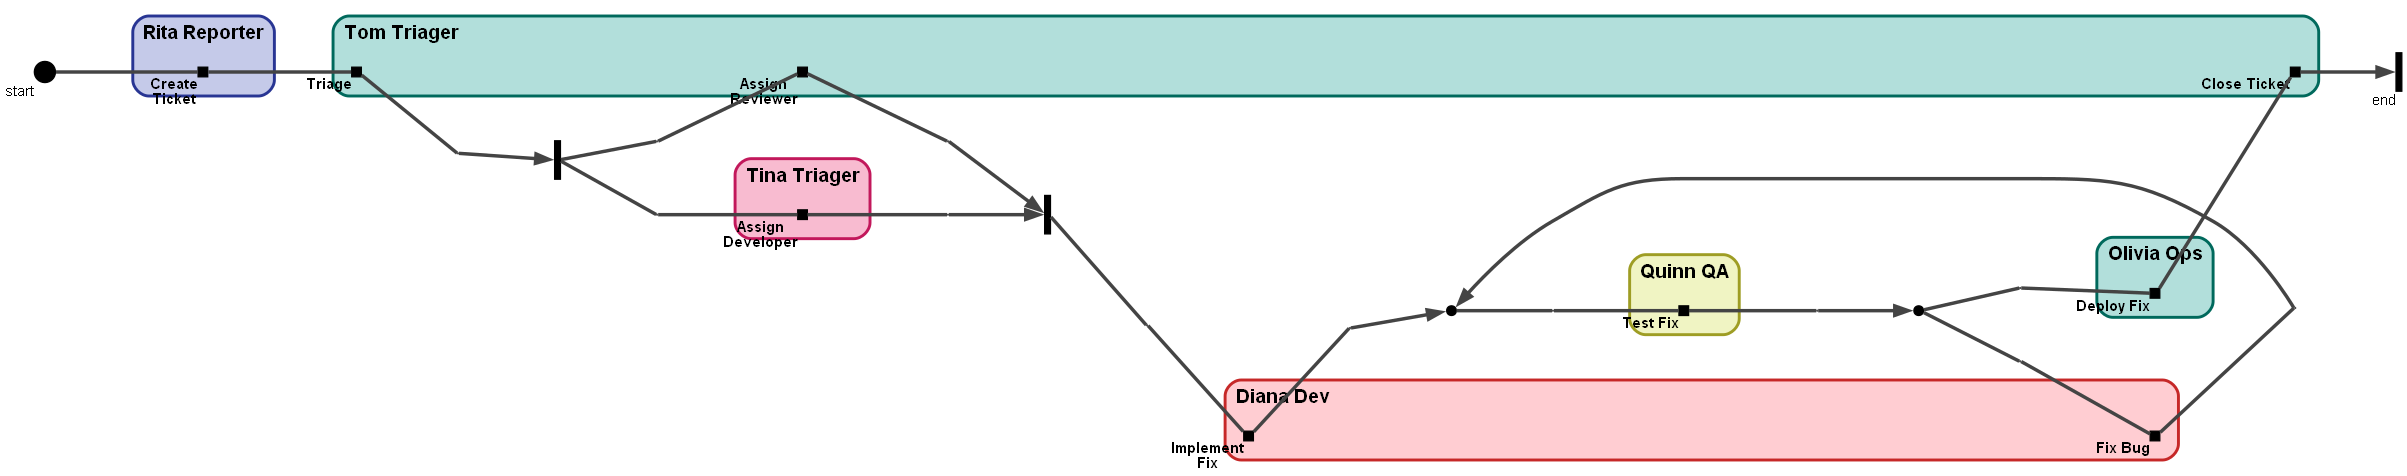

In [5]:
pm4py_ucm.save_vis_ucm(ucm, OUT / "ucm_default.png")
Image(filename=str(OUT / "ucm_default.png"))

### 2.2 Write the `.jucm` (jUCMNav)

`write_ucm` emits jUCMNav-compatible XMI. The same hashed colours
flow through to the `.jucm` as `lineColor` / `fillColor` /
`filled="true"` attributes on each `<components>` definition, so the
diagram looks visually consistent between the Python PNG render and
jUCMNav.

In [6]:
jucm_path = OUT / "claims_default.jucm"
pm4py_ucm.write_ucm(ucm, jucm_path)
print(f"wrote {jucm_path} ({jucm_path.stat().st_size:,} bytes)")
print()
# Peek at the components element
with open(jucm_path, "r", encoding="utf-8") as f:
    for line in f:
        if "<components " in line:
            print(line.rstrip())

wrote output\claims_default.jucm (11,287 bytes)

    <components name="Rita Reporter" id="44" lineColor="40,53,147" fillColor="197,202,233" filled="true" contRefs="29"/>
    <components name="Tom Triager" id="45" lineColor="0,105,92" fillColor="178,223,219" filled="true" contRefs="30"/>
    <components name="Tina Triager" id="46" lineColor="194,24,91" fillColor="248,187,208" filled="true" contRefs="31"/>
    <components name="Diana Dev" id="47" lineColor="198,40,40" fillColor="255,205,210" filled="true" contRefs="32"/>
    <components name="Quinn QA" id="48" lineColor="158,157,36" fillColor="240,244,195" filled="true" contRefs="33"/>
    <components name="Olivia Ops" id="49" lineColor="0,105,92" fillColor="178,223,219" filled="true" contRefs="34"/>
    <components name="Dan Dev" id="50" lineColor="0,105,92" fillColor="178,223,219" filled="true"/>
    <components name="Devesh Dev" id="51" lineColor="194,24,91" fillColor="248,187,208" filled="true"/>
    <components name="Oscar Ops" id="

## 3. BPMN visualisation

If your audience is more comfortable with BPMN than UCM, the same
model can be rendered with BPMN-style symbols — rounded activity
boxes, gateway diamonds with `X`/`+` markers, thin- vs thick-bordered
empty circles for start/end, and a bold `+` decomposition marker on
sub-process stubs. Pass `style="bpmn"`.

This is **not** a conversion of the model — it's just a different
visual rendering of the same `UCM` object. The exported `.jucm`
stays in UCM notation (jUCMNav is a UCM tool).

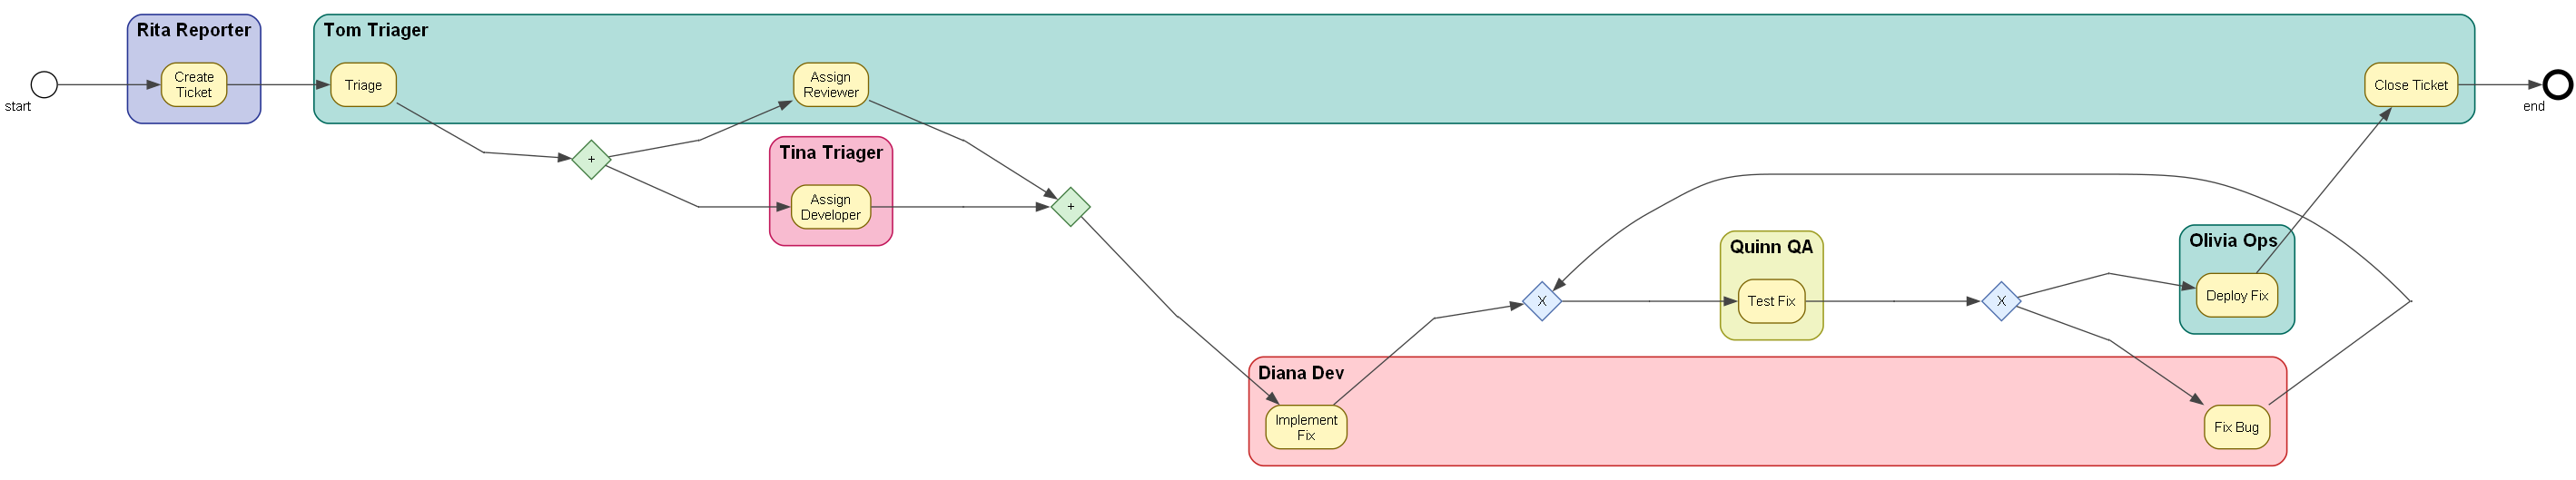

In [7]:
pm4py_ucm.save_vis_ucm(ucm, OUT / "bpmn_default.png", style="bpmn")
Image(filename=str(OUT / "bpmn_default.png"))

## 4. Mining performers

The miner can read activity → performer information from any
event-level attribute. The `resource_attribute` parameter (in the
`parameters` dict) selects which one:

- A **string** like `"org:role"` reads that single attribute.
- A **list** of attribute names is a *priority list* — for each
  event the miner uses the first attribute that is set, falling
  through to the next.
- `False` disables resource mining entirely.
- The default (unspecified) is the fallback list
  `("org:resource", "org:role", "org:group")`.

### 4.1 Prioritise roles over individual resources

Roles like *Claims Officer* are stable across people; individuals
come and go. For an organizational view of who does what, putting
`org:role` first gives a small, readable set of components.

In [8]:
ucm_roles = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"resource_attribute": ["org:role", "org:resource"]},
)
print(f"# components: {len(ucm_roles.components)}")
print()
print("Activity → performer (first 12):")
for r in ucm_roles.responsibilities[:12]:
    perf = r.performer.name if r.performer else "—"
    print(f"  {r.name!r:<35} ← {perf!r}")

# components: 5

Activity → performer (first 12):
  'Create Ticket'                     ← 'Reporter'
  'Triage'                            ← 'Triage Team'
  'Assign Reviewer'                   ← 'Triage Team'
  'Assign Developer'                  ← 'Triage Team'
  'Implement Fix'                     ← 'Dev Team'
  'Test Fix'                          ← 'QA Team'
  'Fix Bug'                           ← 'Dev Team'
  'Deploy Fix'                        ← 'DevOps Team'
  'Close Ticket'                      ← 'Triage Team'


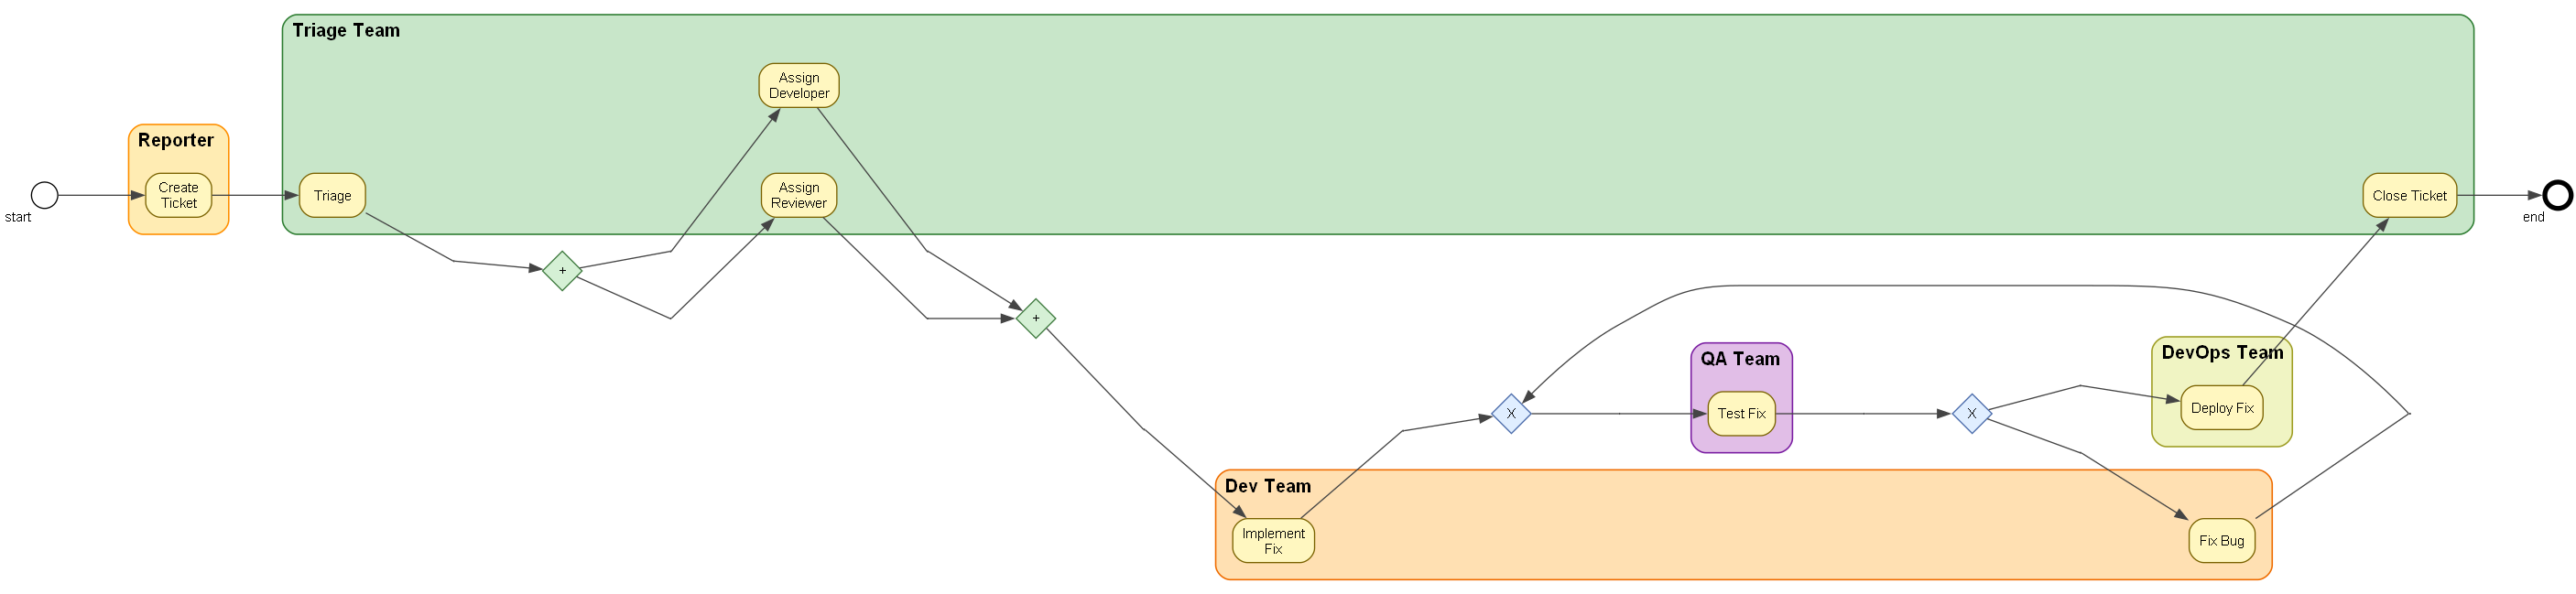

In [9]:
pm4py_ucm.save_vis_ucm(ucm_roles, OUT / "bpmn_roles.png", style="bpmn")
Image(filename=str(OUT / "bpmn_roles.png"))

### 4.2 Prioritise individual resources

If `org:resource` is read first, every individual becomes a separate
component. Useful for spotting handover patterns between specific
people, but visually busier than the role view. The IssueTracker log
has 10 distinct individuals (vs 5 roles) — a small difference here,
but on the `ClaimsPaymentLog` used in section 6 the ratio jumps to
58 individuals vs 10 roles.

*As of pm4py-ucm 0.3.1*, switching `resource_attribute` between
`org:role` and `org:resource` actually produces different models;
a prior enum-aliasing bug meant the role-first priority list was
silently injected on every call, so both choices yielded the role
model regardless.


In [10]:
ucm_resources = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"resource_attribute": ["org:resource"]},
)
print(f"# components: {len(ucm_resources.components)}")
print()
print("First 15 component definitions:")
for c in ucm_resources.components[:15]:
    print(f"  - {c.name}")
print(f"  … ({len(ucm_resources.components) - 15} more)")

# components: 10

First 15 component definitions:
  - Rita Reporter
  - Tom Triager
  - Tina Triager
  - Diana Dev
  - Quinn QA
  - Olivia Ops
  - Dan Dev
  - Devesh Dev
  - Oscar Ops
  - Quincy QA
  … (-5 more)


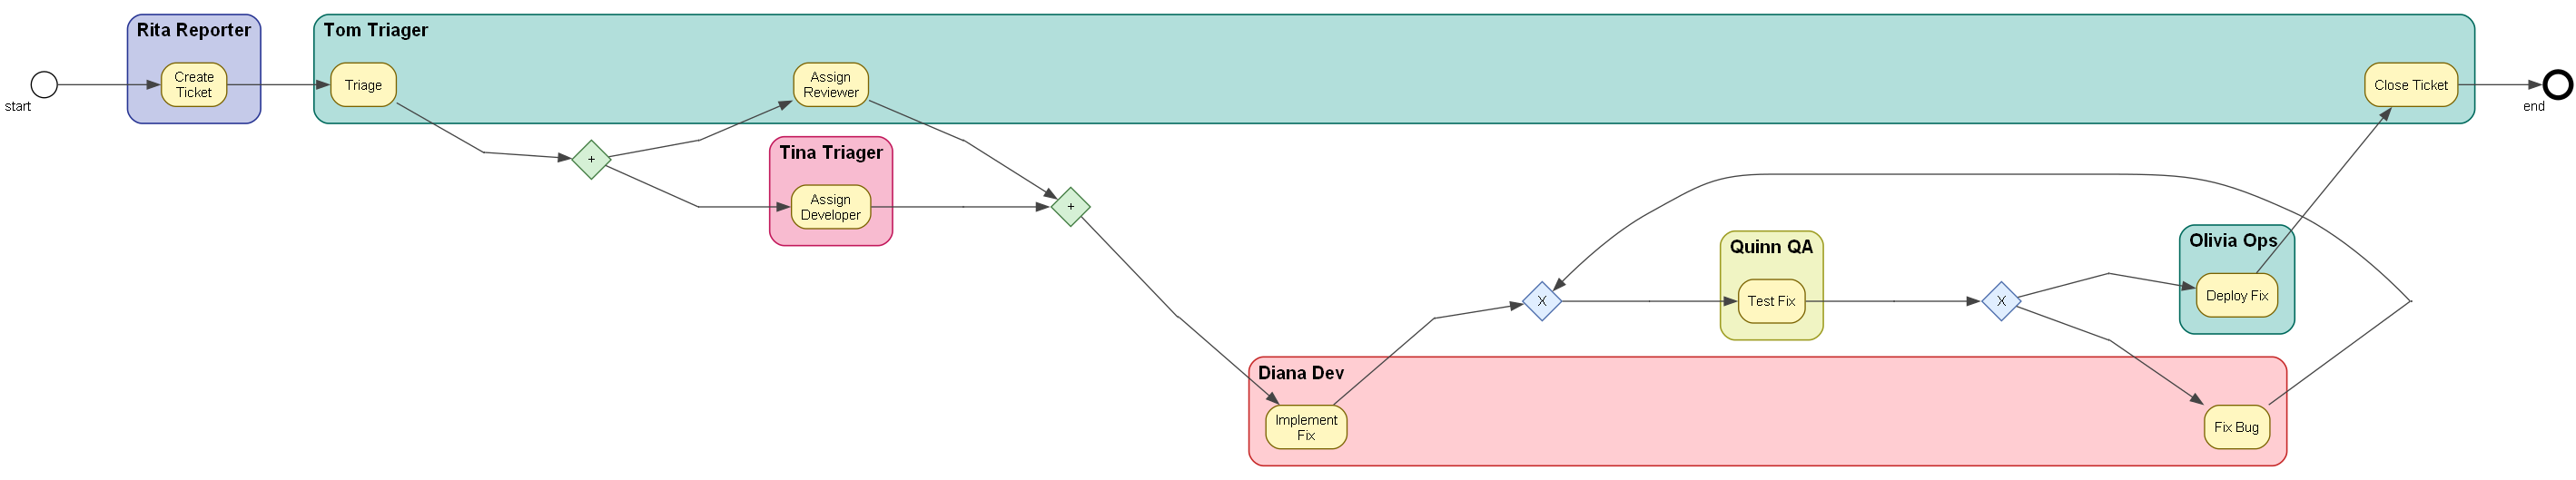

In [11]:
pm4py_ucm.save_vis_ucm(ucm_resources, OUT / "bpmn_resources.png", style="bpmn")
Image(filename=str(OUT / "bpmn_resources.png"))

## 5. Manual performer mappings

Resource mining is convenient but not always what you want — you may
have a "to-be" process model where activities should be assigned to
roles the log doesn't yet reflect. Pass a `{activity: performer}`
dict in `parameters={"performers": …}` and set
`resource_attribute=False` to skip the auto-discovery:

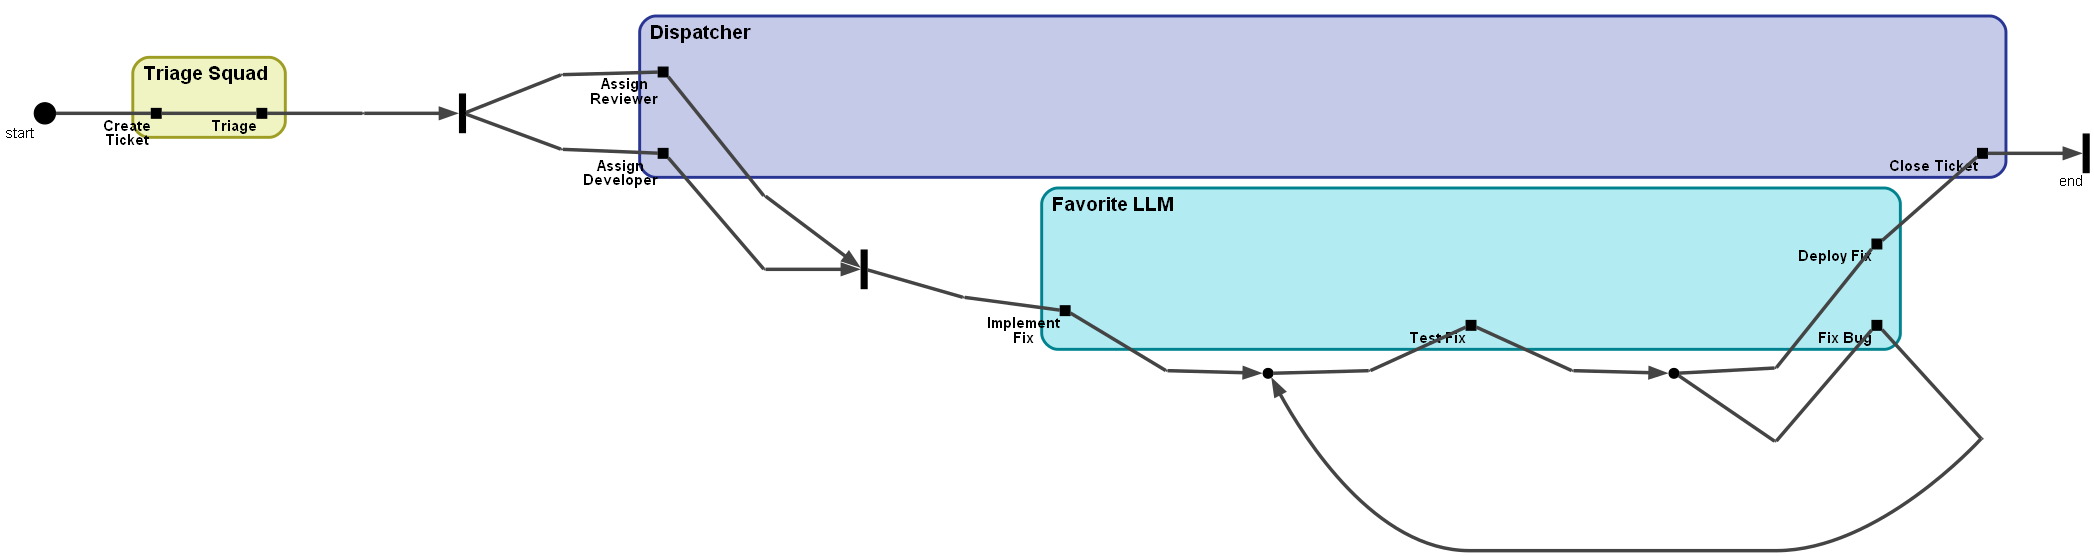

In [12]:
manual_map = {
    "Create Ticket":    "Triage Squad",
    "Triage":           "Triage Squad",
    "Assign Reviewer":  "Dispatcher",
    "Assign Developer": "Dispatcher",
    "Implement Fix":    "Favorite LLM",
    "Test Fix":         "Favorite LLM",
    "Fix Bug":          "Favorite LLM",
    "Deploy Fix":       "Favorite LLM",
    "Close Ticket":     "Dispatcher",
}

ucm_manual = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"performers": manual_map, "resource_attribute": False},
)
pm4py_ucm.save_vis_ucm(ucm_manual, OUT / "ucm_manual.png")
Image(filename=str(OUT / "ucm_manual.png"))

### 5.1 Colours follow the name

Component colours are derived from an MD5 hash of the component's
name, so the same team always gets the same colour across maps and
across runs. Rename the teams and the diagram repaints — but
*consistently*: if you ever come back with the same team names,
you'll get the same colours.

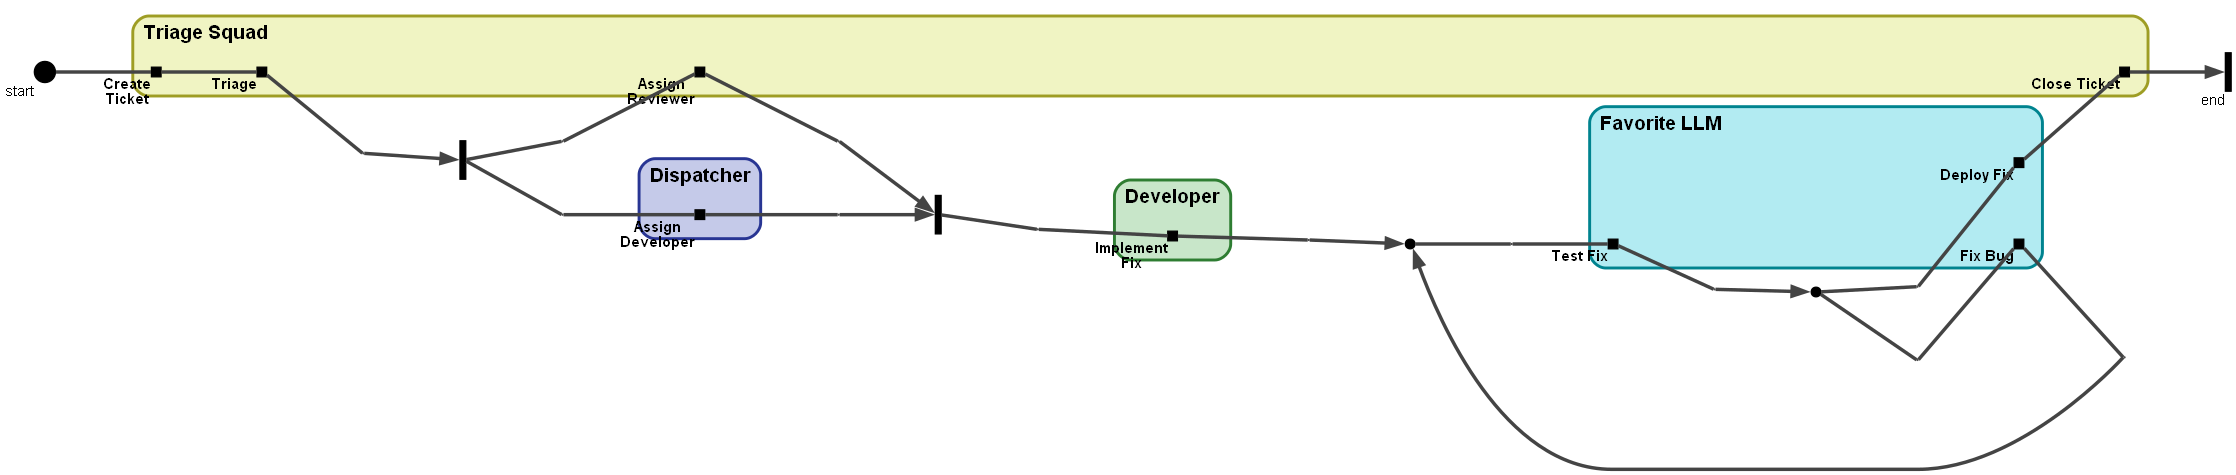

In [13]:
manual_map2 = {
    "Create Ticket":    "Triage Squad",
    "Triage":           "Triage Squad",
    "Assign Reviewer":  "Triage Squad",
    "Assign Developer": "Dispatcher",
    "Implement Fix":    "Developer",
    "Test Fix":         "Favorite LLM",
    "Fix Bug":          "Favorite LLM",
    "Deploy Fix":       "Favorite LLM",
    "Close Ticket":     "Triage Squad",
}

ucm_manual2 = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"performers": manual_map2, "resource_attribute": False},
)
pm4py_ucm.save_vis_ucm(ucm_manual2, OUT / "ucm_manual2.png")
Image(filename=str(OUT / "ucm_manual2.png"))

## 6. Hierarchical decomposition

Real-world process trees can produce huge single-map UCMs that are
hard to read. `pm4py-ucm` can split a tree into a **root map plus
plug-in maps** connected by `Stub` nodes, using **four** semantic
boundary rules that can be combined:

| Rule              | What it cuts                                                                                                            |
|-------------------|-------------------------------------------------------------------------------------------------------------------------|
| `on_root_sequence`| Each child of the top-level `→` (sequence) becomes its own plug-in. The root reads as a chain of phases.                  |
| `on_parallel`     | Each `+` branch becomes a plug-in. Useful when AND-fork/join verticals get tall.                                        |
| `on_alternative`  | Each `×` (XOR) / `∨` (OR) branch becomes a plug-in. *New in 0.3.0.*                                                  |
| `on_loop`         | Each `*` operator's entire expansion becomes a plug-in. The root reads as forward flow with a stub.                     |
| (cap enforcement) | `max_leaves_per_map` recursively cuts the biggest operator subtree of any map that exceeds the cap.                     |

The wrapper preset `"auto"` enables all four with sane defaults
(`max_leaves_per_map=20`, `min_leaves_to_decompose=4`,
`balance_ratio=0.2`). The `"aggressive"` preset uses
`max_leaves_per_map=10` for a stricter cap. When a UCM has multiple
maps, the PNG visualiser composes them vertically into a single
stacked image with title strips for each map.

**Special case: root-level loops** — if the outermost operator of the
input tree is `*` and `on_loop` is enabled, the tree is wrapped in
a synthetic single-child sequence so the loop becomes a cut
candidate. The root map ends up with a single stub pointing to the
loop plug-in, instead of having the full loop machinery drawn
inline. *Fixed in 0.3.0.*

**Tuning the underlying miner.** `discover_ucm_inductive` delegates
process-tree discovery to `pm4py.discover_process_tree_inductive`.
For noisy logs, pass `parameters={"resource_attribute": [...],
"noise_threshold": ...}` indirectly by pre-mining the tree with the
desired threshold and handing it in via
`parameters={"process_tree": tree}` (the section-9.3 pattern). A
threshold of 0.2 is a common practical default; higher values prune
more infrequent behaviour at the cost of perfect fitness.

We'll render each rule in isolation, plus the combined `"auto"`
preset, all in BPMN style.

To exercise decomposition we now switch over to the heavier
``ClaimsPaymentLog.xes`` — its process tree is deeper and denser than
the issue-tracker example, so the different boundary rules produce
visibly different plug-in structures.


In [14]:
LOG_PATH = "ClaimsPaymentLog.xes"
log = pm4py.read_xes(LOG_PATH)
print(f"now using {LOG_PATH}: {len(log):,} events, "
      f"{log['case:concept:name'].nunique():,} cases, "
      f"{log['concept:name'].nunique()} activities")


now using ClaimsPaymentLog.xes: 78,126 events, 5,600 cases, 25 activities


### 6.1 No decomposition — baseline

Single flat map; everything in one diagram. This is what every
previous section produced.

maps: ['DiscoveredMap']


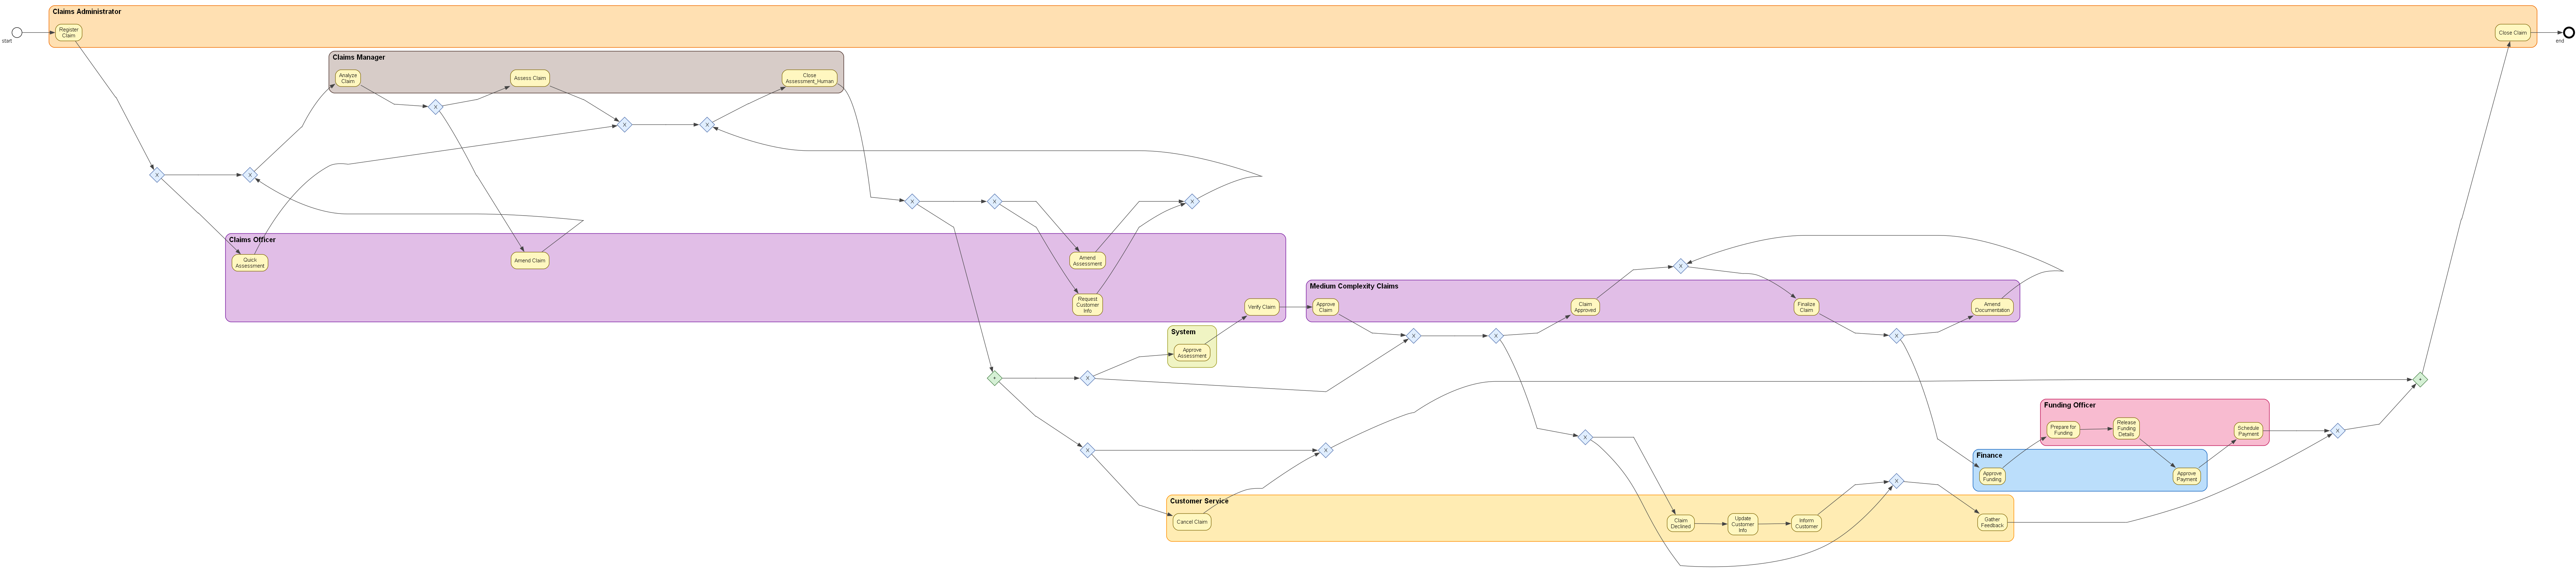

In [15]:
ucm_flat = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"resource_attribute": ["org:role"]},
    decomposition="off",
)
print(f"maps: {[m.name for m in ucm_flat.maps]}")
pm4py_ucm.save_vis_ucm(ucm_flat, OUT / "bpmn_decomp_off.png", style="bpmn")
Image(filename=str(OUT / "bpmn_decomp_off.png"))

### 6.2 `on_root_sequence` only

Each phase of the top-level sequence becomes its own plug-in. The
root map turns into a chain of stub-shaped phases.

# maps: 6
  - DiscoveredMap  (5 resps)
  - Quick Assessment to Assess Claim  (4 resps)
  - Cancel Claim to Schedule Payment  (1 resps)
  - Approve Assessment to Schedule Payment  (3 resps)
  - Claim Declined to Schedule Payment  (4 resps)
  - Claim Approved to Schedule Payment  (8 resps)


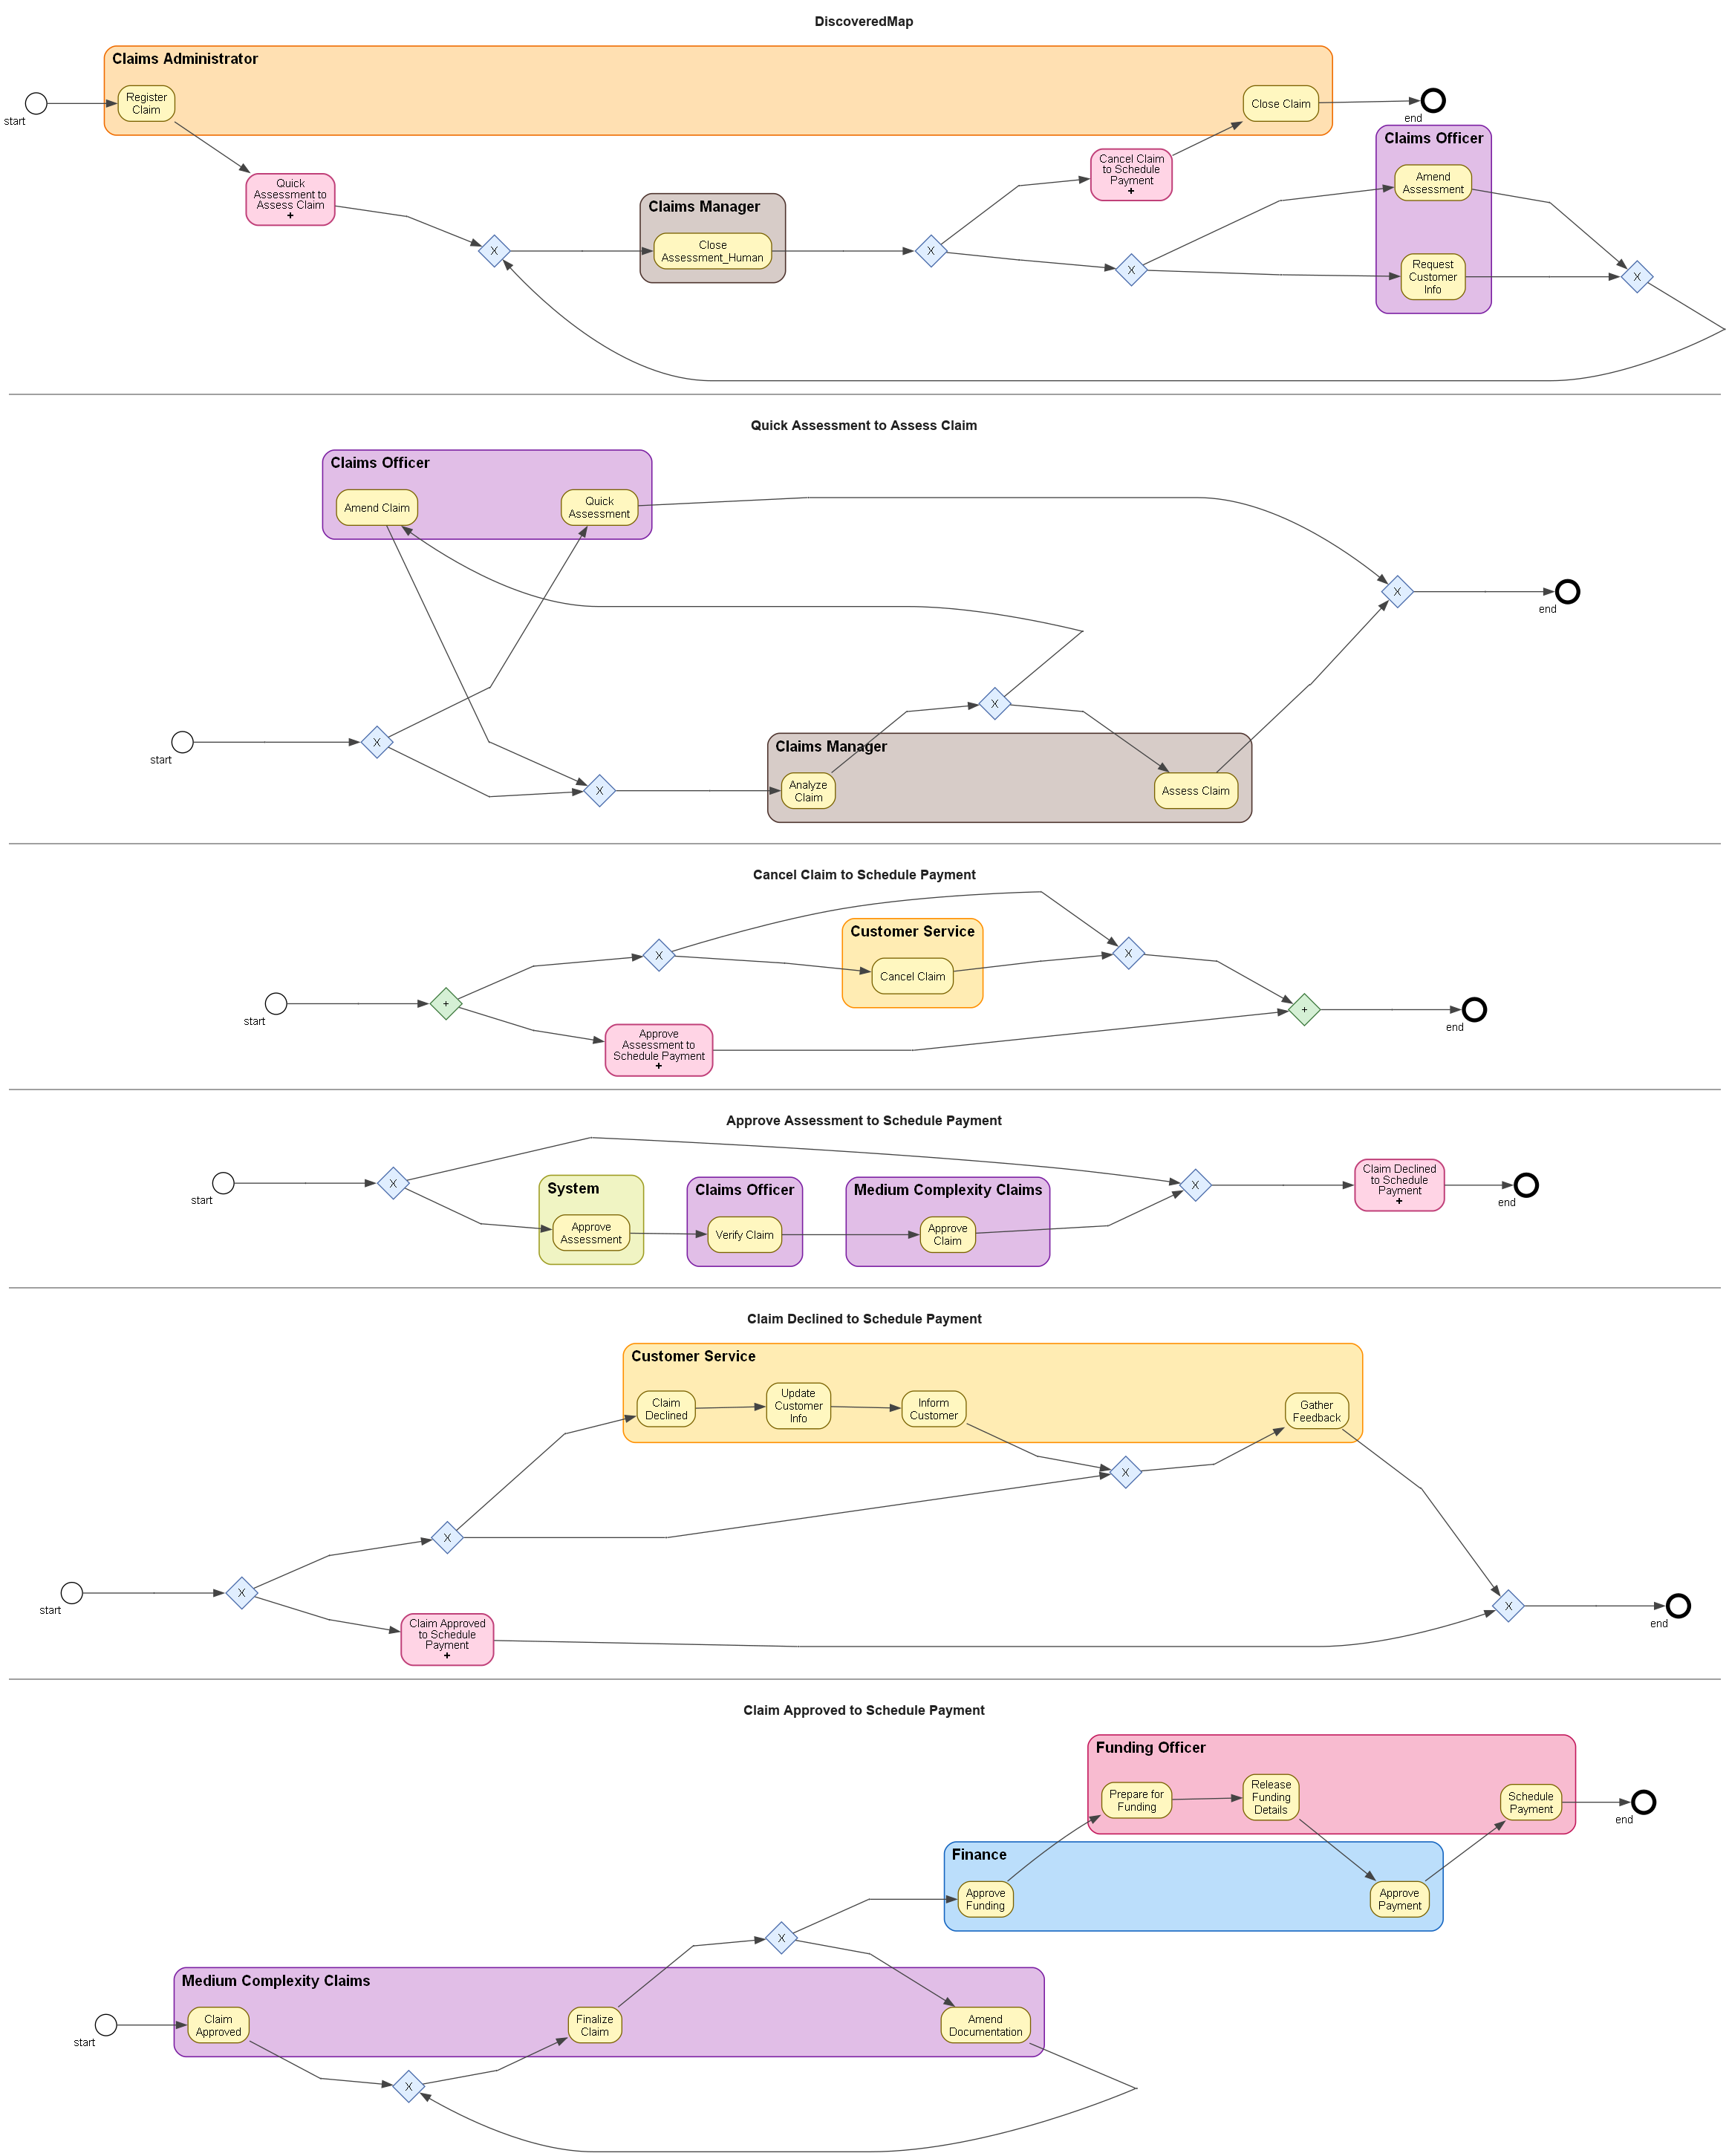

In [16]:
ucm_seq = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"resource_attribute": ["org:role"]},
    decomposition={
        "on_root_sequence": True,
        "on_parallel": False,
        "on_loop": False,
        "on_alternative": False,
        "min_leaves_to_decompose": 4,
        "max_leaves_per_map": 8,
    },
)
print(f"# maps: {len(ucm_seq.maps)}")
for m in ucm_seq.maps:
    print(f"  - {m.name}  ({sum(1 for n in m.nodes if isinstance(n, UCM.RespRef))} resps)")
pm4py_ucm.save_vis_ucm(ucm_seq, OUT / "bpmn_decomp_sequence.png", style="bpmn")
Image(filename=str(OUT / "bpmn_decomp_sequence.png"))

### 6.3 `on_parallel` only

Each parallel branch becomes its own plug-in. The AND-fork/join
machinery stays in the parent map; the *content* of each branch
moves into a sub-map.

In [ ]:
ucm_par = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"resource_attribute": ["org:role"]},
    decomposition={
        "on_root_sequence": False,
        "on_alternative": False,
        "on_parallel": True,
        "on_loop": False,
        "min_leaves_to_decompose": 1,
    },
)
print(f"# maps: {len(ucm_par.maps)}")
pm4py_ucm.save_vis_ucm(ucm_par, OUT / "bpmn_decomp_parallel.png", style="bpmn")
Image(filename=str(OUT / "bpmn_decomp_parallel.png"))

### 6.4 `on_alternative` only — *new in 0.3.0*

Each branch of an `×` (XOR) / `∨` (OR) operator becomes its own
plug-in map (symmetric to `on_parallel`). The OR-fork / OR-join
stays on the parent map; the branch *bodies* move into per-branch
plug-ins. This is the natural treatment for decision-heavy workflows
where each alternative is a self-contained sub-process.

Before 0.3.0, XOR-dominated trees got zero decomposition unless the
leaf cap kicked in — a real gap for claims-style processes which
typically branch on the claim category.


In [ ]:
ucm_alt = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"resource_attribute": ["org:role"]},
    decomposition={
        "on_root_sequence": False,
        "on_parallel": False,
        "on_alternative": True,
        "on_loop": False,
        "min_leaves_to_decompose": 2,
    },
)
print(f"# maps: {len(ucm_alt.maps)}")
for m in ucm_alt.maps:
    resps = sum(1 for n in m.nodes if isinstance(n, UCM.RespRef))
    stubs = sum(1 for n in m.nodes if isinstance(n, UCM.Stub))
    print(f"  - {m.name:<35} ({resps:>2} resps, {stubs:>2} stubs)")
pm4py_ucm.save_vis_ucm(ucm_alt, OUT / "bpmn_decomp_alternative.png", style="bpmn")
Image(filename=str(OUT / "bpmn_decomp_alternative.png"))

### 6.5 `on_loop` only

Each `*` operator's *entire* loop expansion (OR-join + body +
OR-fork + redo branch) becomes a plug-in. The parent reads as
forward flow with a stub standing in for the iteration.

In [ ]:
ucm_loop = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"resource_attribute": ["org:role"]},
    decomposition={
        "on_root_sequence": False,
        "on_alternative": False,
        "on_parallel": False,
        "on_loop": True,
        "min_leaves_to_decompose": 1,
    },
)
print(f"# maps: {len(ucm_loop.maps)}")
pm4py_ucm.save_vis_ucm(ucm_loop, OUT / "bpmn_decomp_loop.png", style="bpmn")
Image(filename=str(OUT / "bpmn_decomp_loop.png"))

### 6.6 `"auto"` preset — all four rules

Combines all four boundary rules plus the leaf-cap safety net.
For this log, this is usually the most readable rendering.


In [ ]:
ucm_auto = pm4py_ucm.discover_ucm_inductive(
    LOG_PATH,
    parameters={"resource_attribute": ["org:role"]},
    decomposition="auto",
)
print(f"# maps: {len(ucm_auto.maps)}")
for m in ucm_auto.maps:
    resps = sum(1 for n in m.nodes if isinstance(n, UCM.RespRef))
    stubs = sum(1 for n in m.nodes if isinstance(n, UCM.Stub))
    print(f"  - {m.name:<35} ({resps:>2} resps, {stubs:>2} stubs)")
pm4py_ucm.save_vis_ucm(ucm_auto, OUT / "bpmn_decomp_auto.png", style="bpmn")
Image(filename=str(OUT / "bpmn_decomp_auto.png"))

### 6.7 Filter to a single map

`save_vis_ucm` (and `view_ucm`) accept a `map=` keyword to render
just one plug-in instead of the whole stack — handy when drilling
into a specific phase.

In [ ]:
if len(ucm_auto.maps) > 1:
    plugin_name = ucm_auto.maps[1].name
    print(f"Rendering plug-in: {plugin_name!r}")
    pm4py_ucm.save_vis_ucm(ucm_auto, OUT / "bpmn_decomp_single.png",
                            style="bpmn", map=plugin_name)
    display(Image(filename=str(OUT / "bpmn_decomp_single.png")))

### 6.8 Root-level loops — the wrap fix

When the outermost operator of the input tree is `*` and `on_loop`
is enabled, the tree is wrapped in a synthetic single-child sequence
so the loop becomes a cut candidate. The root map ends up with a
single stub pointing to the loop plug-in, instead of having the full
loop machinery drawn inline.

We can't demonstrate this directly from `ClaimsPaymentLog` (its
top-level operator is `→`, not `*`), so we hand-build a tiny tree
whose root is a loop and run it through `convert_to_ucm`.


In [ ]:
class T:
    """Minimal duck-typed process-tree node."""
    def __init__(self, operator=None, label=None, children=None):
        self.operator = operator
        self.label = label
        self.children = children or []
seq = lambda *labels: T(operator="->", children=[T(label=l) for l in labels])

# A tree whose root IS a loop. Before 0.3.0, on_loop=True would do
# nothing here — the loop machinery would still be drawn inline in
# the root map. The 0.3.0 wrap fix makes it actually decompose.
loop_root_tree = T(operator="*", children=[
    seq("Review Item", "Update Status", "Notify Watchers"),
    T(label=None),     # tau / silent redo → no body
])

ucm_root_loop = pm4py_ucm.convert_to_ucm(
    loop_root_tree,
    decomposition={
        "on_root_sequence": False,
        "on_parallel": False,
        "on_alternative": False,
        "on_loop": True,
        "min_leaves_to_decompose": 2,
    },
)
print(f"# maps: {len(ucm_root_loop.maps)}")
for m in ucm_root_loop.maps:
    print(f"  - {m.name}")
pm4py_ucm.save_vis_ucm(ucm_root_loop, OUT / "bpmn_root_loop.png", style="bpmn")
Image(filename=str(OUT / "bpmn_root_loop.png"))

## 7. Export to `.jucm` and read back

`write_ucm` emits jUCMNav-compatible XMI; `read_ucm` parses it back
into a Python `UCM` instance. The round-trip is byte-stable
(modulo the `created` / `modified` timestamps stamped at write
time) — re-exporting the parsed model produces identical XML.

In [ ]:
jucm_path = OUT / "claims_auto.jucm"
pm4py_ucm.write_ucm(ucm_auto, jucm_path)
print(f"wrote {jucm_path} ({jucm_path.stat().st_size:,} bytes)")

# Read it back
ucm_loaded = pm4py_ucm.read_ucm(str(jucm_path))
print()
print(f"loaded: {ucm_loaded}")
print(f"  maps match: {[m.name for m in ucm_loaded.maps] == [m.name for m in ucm_auto.maps]}")
print(f"  components: {len(ucm_loaded.components)}")
print(f"  responsibilities: {len(ucm_loaded.responsibilities)}")

The loaded model renders identically. Open the `.jucm` in jUCMNav
itself to see the same colours and decomposition the PNG shows —
plug-in maps appear as a separate diagram you can drill into.

In [ ]:
pm4py_ucm.save_vis_ucm(ucm_loaded, OUT / "ucm_loaded.png")
Image(filename=str(OUT / "ucm_loaded.png"))

## 8. Build a UCM programmatically

You don't need an event log at all — `pm4py-ucm` exposes both
levels of authoring, depending on how concrete your model already
is:

* **8.1** build the `UCM` graph yourself, node-by-node. Best when
  you know exactly which symbols go where (reference models,
  to-be sketches, unit tests).
* **8.2** describe the *process tree* and let the converter
  produce the UCM for you. Best when you're sketching the
  underlying control flow rather than the diagram.

### 8.1 …directly via the `UCM` object model

A tiny three-actor model with a parallel split, built straight
against the `UCM` class.


In [ ]:
ucm_built = UCM(name="HandBuilt")
m = ucm_built.add_map(name="Order Fulfilment")

# URN-level component definitions and visual ComponentRefs on the map
sales       = ucm_built.get_or_add_component("Sales")
warehouse   = ucm_built.get_or_add_component("Warehouse")
finance     = ucm_built.get_or_add_component("Finance")
ref_sales   = m.add_component_ref(sales)
ref_wh      = m.add_component_ref(warehouse)
ref_fin     = m.add_component_ref(finance)

# Path: start → Receive Order → AND-fork → (Pick Items, Charge Card) → AND-join → Ship → end
start = m.add_node(UCM.StartPoint(name="start"))
end   = m.add_node(UCM.EndPoint(name="end"))

receive = m.add_node(UCM.RespRef(
    name="Receive Order",
    resp_def=ucm_built.get_or_add_responsibility("Receive Order"),
))
receive.cont_ref = ref_sales

af = m.add_node(UCM.AndFork(name="AndFork"))
aj = m.add_node(UCM.AndJoin(name="AndJoin"))

pick = m.add_node(UCM.RespRef(
    name="Pick Items",
    resp_def=ucm_built.get_or_add_responsibility("Pick Items"),
))
pick.cont_ref = ref_wh

charge = m.add_node(UCM.RespRef(
    name="Charge Card",
    resp_def=ucm_built.get_or_add_responsibility("Charge Card"),
))
charge.cont_ref = ref_fin

ship = m.add_node(UCM.RespRef(
    name="Ship Package",
    resp_def=ucm_built.get_or_add_responsibility("Ship Package"),
))
ship.cont_ref = ref_wh

m.add_connection(start, receive)
m.add_connection(receive, af)
m.add_connection(af, pick)
m.add_connection(af, charge)
m.add_connection(pick, aj)
m.add_connection(charge, aj)
m.add_connection(aj, ship)
m.add_connection(ship, end)

# Wire performers semantically (so the model knows Pick Items is done by Warehouse)
ucm_built.bind_performers({
    "Receive Order": "Sales",
    "Pick Items":    "Warehouse",
    "Charge Card":   "Finance",
    "Ship Package":  "Warehouse",
})

print(ucm_built)

In [ ]:
pm4py_ucm.save_vis_ucm(ucm_built, OUT / "ucm_built.png")
Image(filename=str(OUT / "ucm_built.png"))

In [ ]:
# Export to .jucm — opens directly in jUCMNav
hand_jucm = OUT / "hand_built.jucm"
pm4py_ucm.write_ucm(ucm_built, hand_jucm)
print(f"wrote {hand_jucm} — open it in jUCMNav to see the same model.")

### 8.2 …from a hand-built process tree

For something larger, hand-build the process tree and let
`convert_to_ucm` do the work. The tiny `T` helper below mirrors the
duck-typing contract the converter expects — `operator` is one of
PM4Py's process-tree operator strings (`"->"` for sequence, `"+"`
for parallel, `"*"` for loop, `"X"` for exclusive choice),
`label` is the activity name for leaves, and `children` is the
list of sub-trees.

We pair the tree with a manual `performers` mapping so the
discovered UCM has the actor swim-lanes we expect.


In [ ]:
class T:
    """Minimal duck-typed process-tree node — matches what
    ``convert_to_ucm`` (and PM4Py) expect."""
    def __init__(self, operator=None, label=None, children=None):
        self.operator = operator
        self.label = label
        self.children = children or []

# Convenience: a flat sequence of activity leaves.
seq = lambda *labels: T(operator="->", children=[T(label=l) for l in labels])

tree = T(operator="->", children=[
    seq("Create Ticket", "Triage", "Assign Engineer"),
    T(operator="+", children=[
        seq("Reserve Build Slot", "Snapshot Repo"),
        seq("Notify Reviewer", "Wait for Approval"),
    ]),
    T(operator="*", children=[
        seq("Implement Fix", "Test Fix", "Code Review"),
        T(label=None),   # tau / silent → no redo body
    ]),
    seq("Deploy Fix", "Close Ticket"),
])

performers = {
    "Create Ticket":      "Front Office",
    "Triage":             "Front Office",
    "Assign Engineer":    "Front Office",
    "Reserve Build Slot": "DevOps",
    "Snapshot Repo":      "DevOps",
    "Notify Reviewer":    "Code Reviewers",
    "Wait for Approval":  "Code Reviewers",
    "Implement Fix":      "Dev Team",
    "Test Fix":           "QA Team",
    "Code Review":        "Code Reviewers",
    "Deploy Fix":         "DevOps",
    "Close Ticket":       "Front Office",
}

ucm_from_tree = pm4py_ucm.convert_to_ucm(
    tree,
    parameters={"performers": performers},
    decomposition="auto",
)
print(f"# maps: {len(ucm_from_tree.maps)}")
for m in ucm_from_tree.maps:
    resps = sum(1 for n in m.nodes if isinstance(n, UCM.RespRef))
    stubs = sum(1 for n in m.nodes if isinstance(n, UCM.Stub))
    print(f"  - {m.name:<35} ({resps:>2} resps, {stubs:>2} stubs)")


In [ ]:
pm4py_ucm.save_vis_ucm(ucm_from_tree, OUT / "ucm_from_tree.png")
Image(filename=str(OUT / "ucm_from_tree.png"))


## 9. Useful extras

A grab-bag of helpers worth knowing about.

### 9.1 `discover_resources` — just the mapping

If all you want is the `{activity: performer}` dict (e.g. to inspect
or tweak before passing it to `bind_performers`), call
`discover_resources` directly:

In [ ]:
mapping = pm4py_ucm.discover_resources(
    log, attribute="org:role", strategy="mode",
)
print("Top-10 activity→role bindings by frequency:")
for k, v in list(mapping.items())[:10]:
    print(f"  {k!r:<35} → {v!r}")

### 9.2 `discover_components` — the full vocabulary

`discover_components` returns every distinct value seen for the
chosen attribute — even ones not bound to any specific activity.
Useful when the log contains "lurking" actors you still want
represented in the URN model:

In [ ]:
vocab = pm4py_ucm.discover_components(log, attribute="org:role")
print(f"all roles seen in log: {len(vocab)}")
print(vocab)

### 9.3 Inspect the underlying process tree

The miner is `pm4py.discover_process_tree_inductive` under the hood;
the converter then turns that tree into a UCM. You can supply your
own tree via `parameters={"process_tree": …}` to skip the discovery
and only run the conversion — handy if you've built a tree by hand
or want to control its shape.

In [ ]:
tree = pm4py.discover_process_tree_inductive(log)
print(str(tree)[:400] + "…")

## 10. Wrap-up

You've now seen:

- end-to-end discovery from event log to UCM (PNG + `.jucm`);
- both visual styles (UCM and BPMN);
- performer mining with role vs resource priority (correctly
  distinct from 0.3.1 on);
- manual performer mapping with deterministic colours;
- all five decomposition modes (off, sequence, parallel,
  **alternative** *(new in 0.3.0)*, loop, auto);
- the **root-loop wrap fix** so a top-level `*` actually decomposes;
- `.jucm` round-trips;
- programmatic UCM construction.

For more, see:

- The package [README](https://github.com/ProcessMining-uOttawa/pm4py-ucm#readme).
- The [CHANGELOG](https://github.com/ProcessMining-uOttawa/pm4py-ucm/blob/main/CHANGELOG.md)
  for what landed in each release.
- jUCMNav docs at https://github.com/JUCMNAV/projetseg.
- The PM4Py docs for the upstream miners we delegate to.
